In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Data/raw/trainincome_data.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  Income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
df.shape

(32561, 15)

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
for col in df.columns:
    print("Column:", col)
    print(df[col].unique())
    print("------")

Column: age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
------
Column: workclass
<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str
------
Column: fnlwgt
[ 77516  83311 215646 ...  34066  84661 257302]
------
Column: education
<StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str
------
Column: education-num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
------
Column: marital-s

In [9]:
object_cols = df.select_dtypes(include=['object', 'string']).columns
for col in object_cols:
    df[col] = df[col].str.strip()


In [10]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
df.describe(include='string')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,Income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [12]:
df = df.drop_duplicates().reset_index(drop=True)

In [13]:
df.duplicated().sum()

np.int64(0)

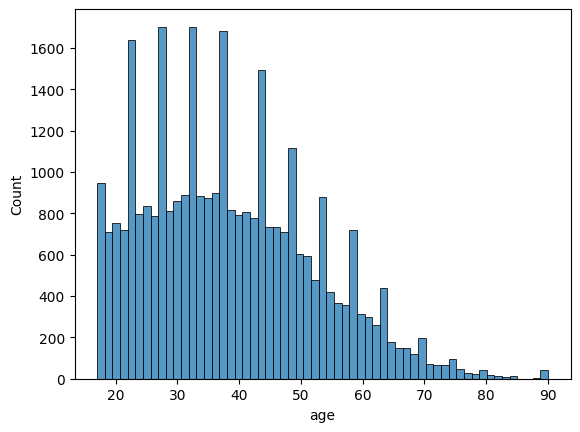

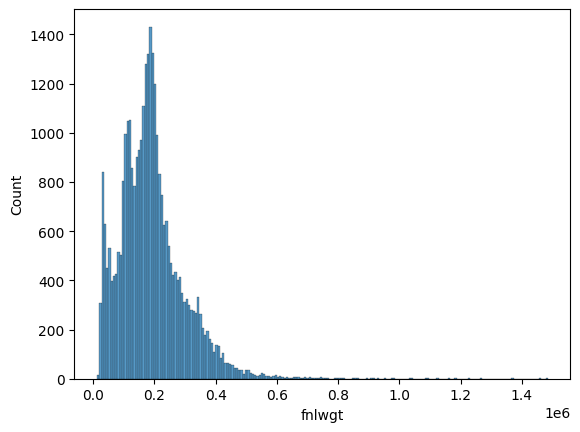

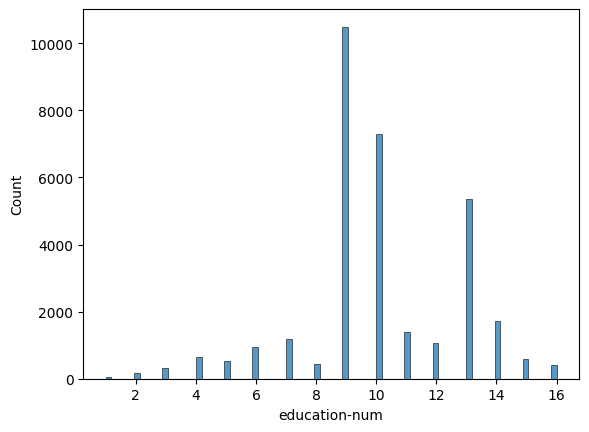

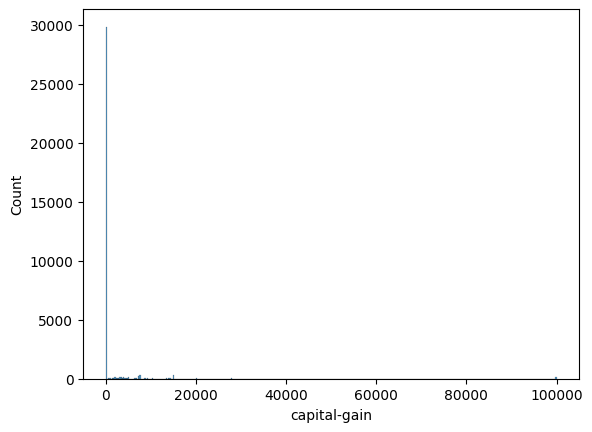

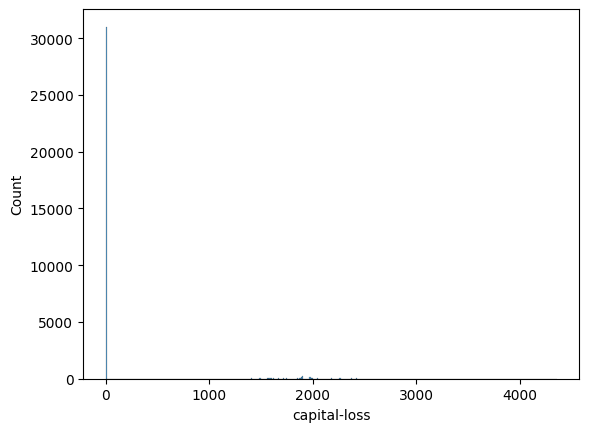

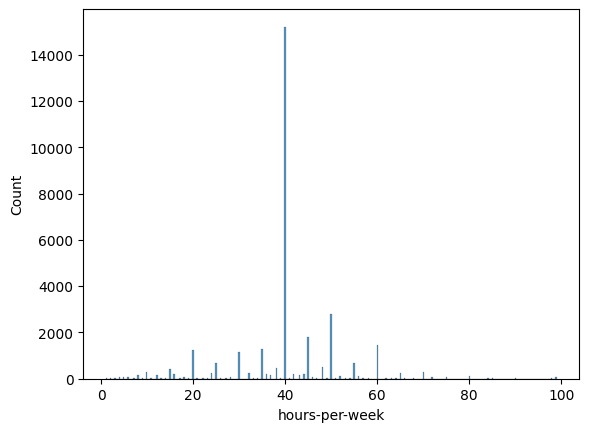

In [14]:
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()

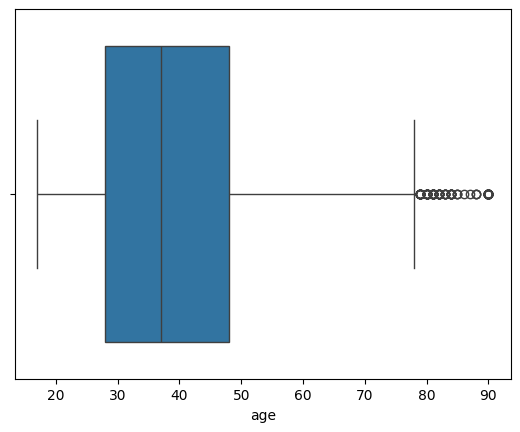

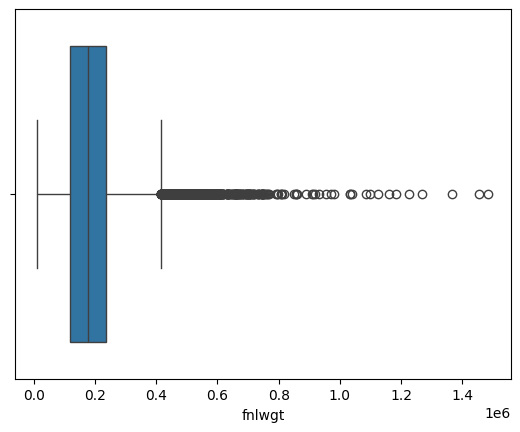

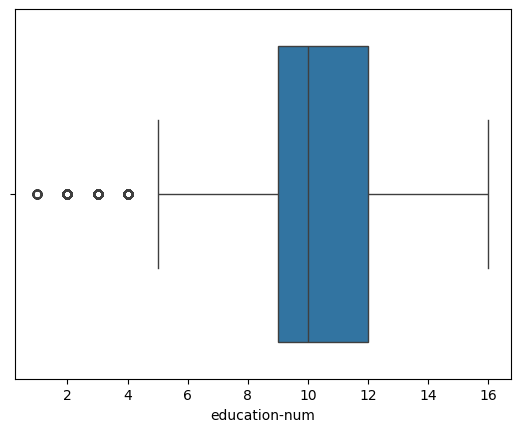

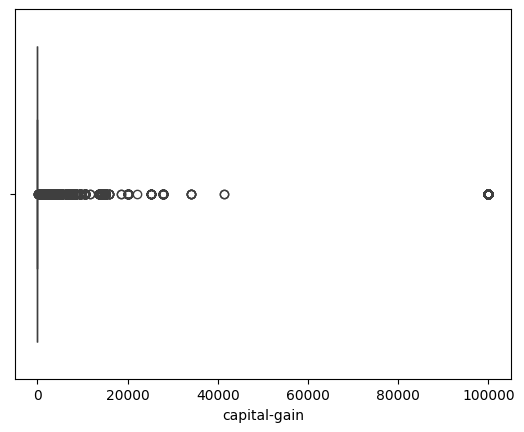

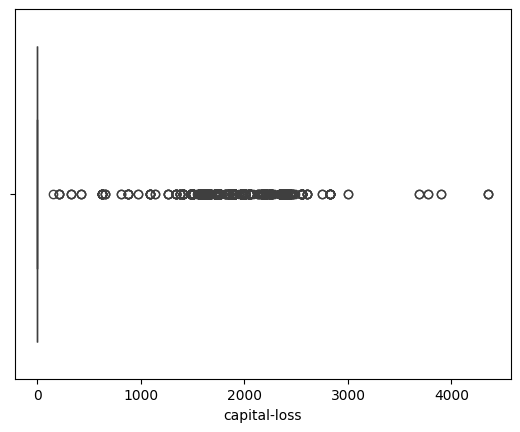

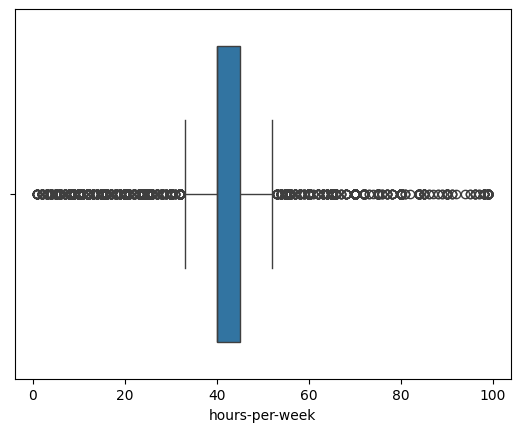

In [15]:
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show() 

<Axes: xlabel='age', ylabel='hours-per-week'>

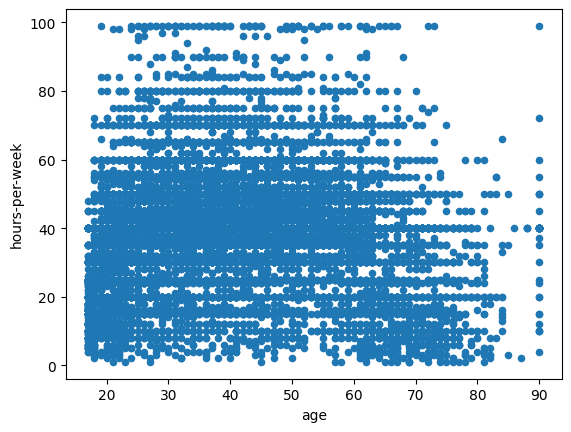

In [16]:
df.plot.scatter(x='age', y='hours-per-week')

<Axes: xlabel='age', ylabel='education-num'>

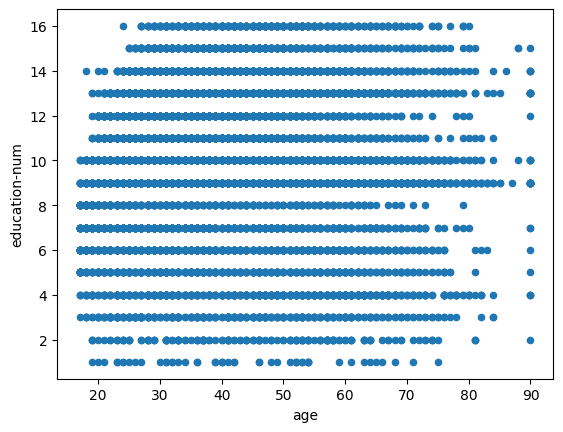

In [17]:
df.plot.scatter(x='age', y='education-num')

<Axes: xlabel='hours-per-week', ylabel='education-num'>

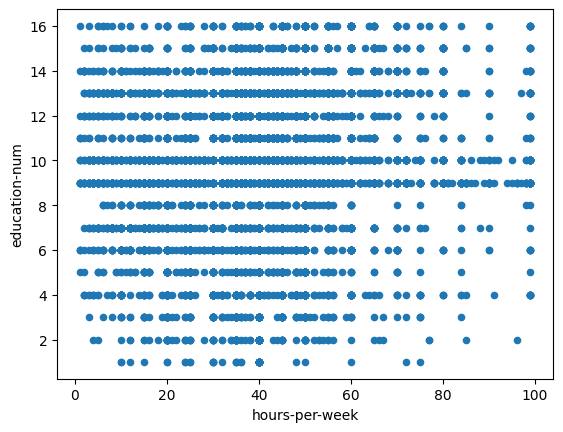

In [18]:
df.plot.scatter(x='hours-per-week', y='education-num')

In [19]:
# there is no correlation between the features
df.select_dtypes(include="number").corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898
education-num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422
capital-gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408
capital-loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229
hours-per-week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000


<Axes: >

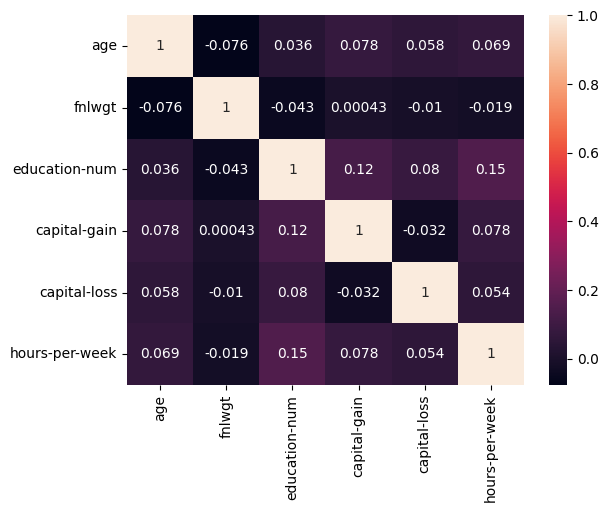

In [20]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)

<Axes: xlabel='education', ylabel='count'>

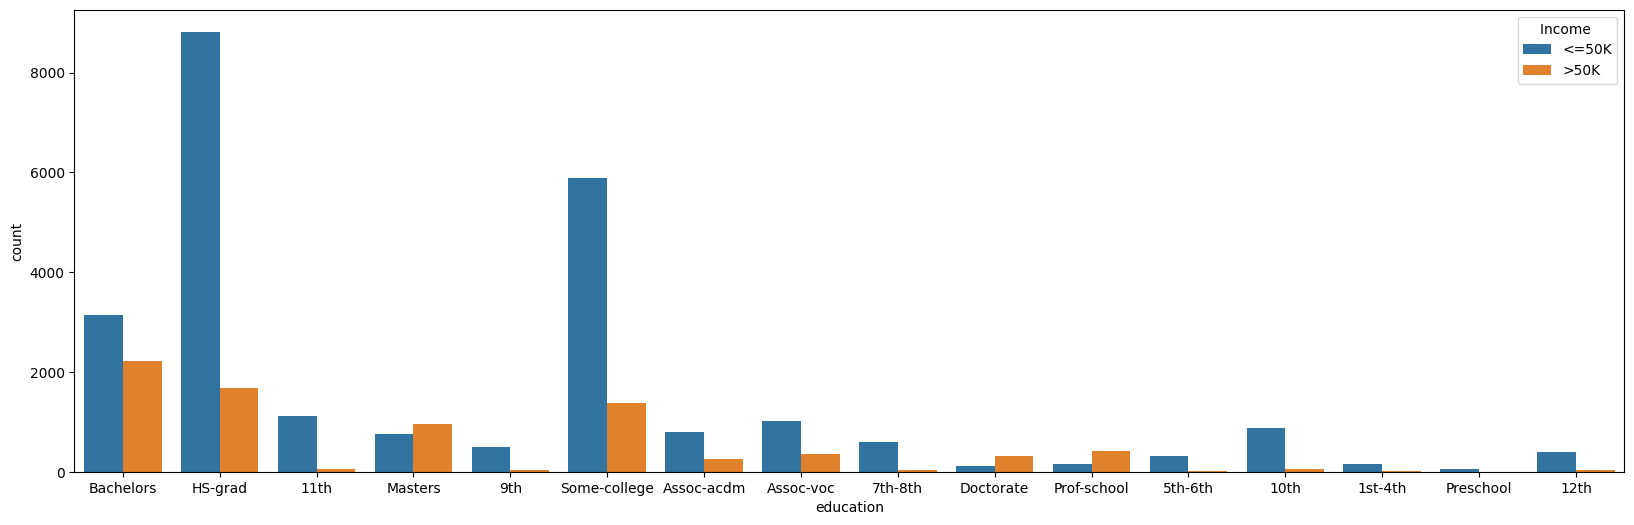

In [21]:
plt.figure(figsize=(20, 6))
sns.countplot(x='education', hue='Income ', data=df)

In [22]:
# handling garbage values
df.replace('?', np.nan, inplace=True)
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
df.isnull().values.any()

np.False_

In [24]:
(df == "unknown").sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [25]:
num_cols=df.select_dtypes(include='int64').columns
print(num_cols)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='str')


In [26]:
def outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return print(column,":",outliers.shape[0])
      

for col in num_cols :
    outliers_iqr(df,col)

age : 142
fnlwgt : 993
education-num : 1193
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9002


In [27]:
df['capital-gain']=np.log1p(df['capital-gain'])
df['capital-loss']=np.log1p(df['capital-loss'])

<Axes: xlabel='capital-gain'>

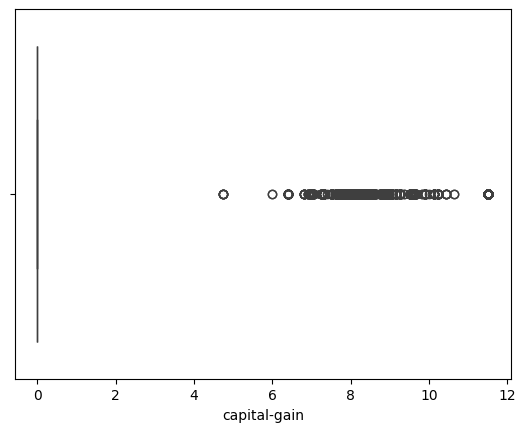

In [28]:
sns.boxplot(data=df,x=df['capital-gain'])

<Axes: xlabel='capital-loss'>

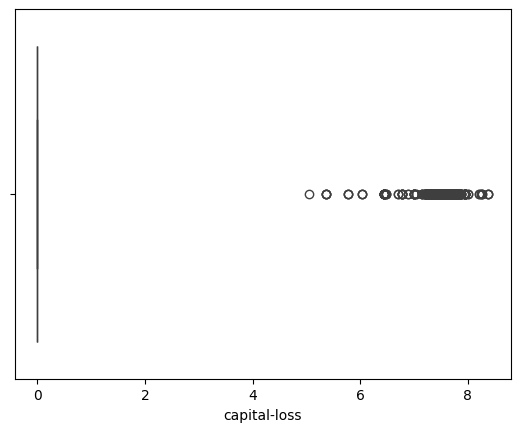

In [29]:
sns.boxplot(data=df,x=df['capital-loss'])

In [30]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['age'] = df['age'].clip(lower, upper)

In [31]:
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['hours-per-week'] = df['hours-per-week'].clip(lower, upper)

<Axes: xlabel='age'>

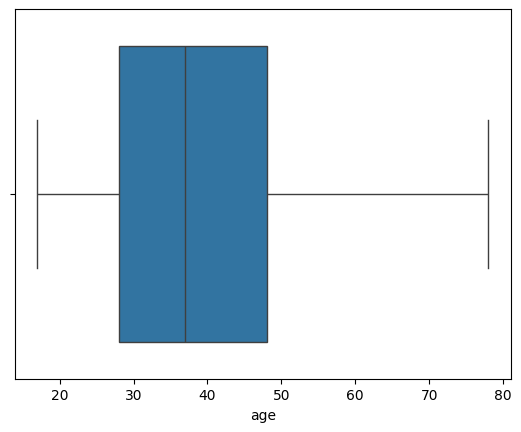

In [32]:
sns.boxplot(data=df,x=df['age'])

<Axes: xlabel='hours-per-week'>

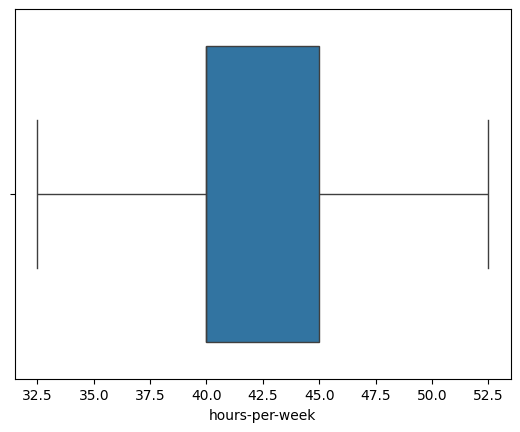

In [33]:
sns.boxplot(data=df,x=df['hours-per-week'])

In [34]:
df.duplicated().sum()

np.int64(16)

In [35]:
if 'fnlwgt' in df.columns:
    df.drop('fnlwgt', axis=1, inplace=True)
    print("Column 'fnlwgt' has been dropped.")
else:
    print("Column 'fnlwgt' not found - it was already dropped.")

Column 'fnlwgt' has been dropped.


In [36]:
df.columns.tolist()

['age',
 'workclass',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'Income ']

In [37]:
df.duplicated().sum()

np.int64(4497)

In [38]:
df[df.duplicated()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
352,33,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
371,17,Private,11th,7,Never-married,Other-service,Own-child,White,Male,0.0,0.0,32.5,United-States,<=50K
391,27,Private,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0.0,0.0,50.0,United-States,<=50K
517,20,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Male,0.0,0.0,32.5,United-States,<=50K
563,24,Private,HS-grad,9,Never-married,Handlers-cleaners,Unmarried,Black,Female,0.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32488,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32503,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32518,72,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K
32533,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K


In [39]:
df[df.duplicated(keep=False)]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
12,23,Private,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Female,0.0,0.0,32.5,United-States,<=50K
17,32,Private,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,White,Male,0.0,0.0,40.0,United-States,<=50K
20,40,Private,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,52.5,United-States,>50K
26,19,Private,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
29,49,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32488,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32503,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32518,72,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K
32533,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K


In [40]:
df=df.drop_duplicates()

In [41]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32530    False
32531    False
32532    False
32534    False
32536    False
Length: 28040, dtype: bool

In [42]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# x_train = df.select_dtypes(include='number')
# X_train_scaled = scaler.fit_transform(x_train)

In [43]:
# print(X_train_scaled)

In [44]:
# scaled_df = pd.DataFrame(X_train_scaled, columns=x_train.columns)
# print(scaled_df.head())

In [45]:
# scaled_df.describe()

In [46]:
# print("Before scaling:")
# print(x_train.describe())

# print("\nAfter scaling:")
# print(scaled_df.describe())

In [47]:
one_hot_cols = [
    'sex',
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'native-country'
]
ordinal_cols=['education']

In [48]:
df=pd.get_dummies(df,columns=one_hot_cols)

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
education_order = [
    'Preschool',
    '1st-4th',
    '5th-6th',
    '7th-8th',
    '9th',
    '10th',
    '11th',
    '12th',
    'HS-grad',
    'Some-college',
    'Assoc-voc',
    'Assoc-acdm',
    'Bachelors',
    'Masters',
    'Prof-school',
    'Doctorate'
]

In [51]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder(categories=[education_order])
df['education']=encoder.fit_transform(df[['education']])

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.head()

,age,education,education-num,capital-gain,capital-loss,hours-per-week,Income,sex_Female,sex_Male,workclass_Federal-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,12.0,13,7.684784,0.0,40.0,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,50,12.0,13,0.000000,0.0,32.5,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38,8.0,9,0.000000,0.0,40.0,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,6.0,7,0.000000,0.0,40.0,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,12.0,13,0.000000,0.0,40.0,<=50K,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
print(df['education'].unique())

[12.  8.  6. 13.  4.  9. 11. 10.  3. 15. 14.  2.  5.  1.  0.  7.]


In [55]:
print(df.select_dtypes(include='object').columns)

Index(['Income '], dtype='str')


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18836\2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Income '] = le.fit_transform(df['Income '])

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.head()

,age,education,education-num,capital-gain,capital-loss,hours-per-week,Income,sex_Female,sex_Male,workclass_Federal-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,12.0,13,7.684784,0.0,40.0,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,50,12.0,13,0.000000,0.0,32.5,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38,8.0,9,0.000000,0.0,40.0,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,6.0,7,0.000000,0.0,40.0,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,12.0,13,0.000000,0.0,40.0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [59]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='str')


In [60]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Income ', axis=1)  
y = df['Income ']   
numeric_cols = ['age', 'education', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X[numeric_cols])
X_numeric_scaled = pd.DataFrame(X_numeric_scaled, columns=numeric_cols, index=X.index)  
X_categorical = X.drop(columns=numeric_cols)
X_final = pd.concat([X_numeric_scaled, X_categorical], axis=1)

In [61]:
X_numeric_scaled.duplicated().sum()

np.int64(19672)

In [62]:
X_categorical.duplicated().sum()

np.int64(23983)

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
# X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_cols)

In [65]:
# X_final = pd.concat([X_numeric_scaled_df, X.drop(columns=numeric_cols)], axis=1)

In [66]:
print(X_final.shape)
print(y.shape)

(28040, 89)
(28040,)


In [67]:
X_final.isnull().sum()

age                               0
education                         0
education-num                     0
capital-gain                      0
capital-loss                      0
                                 ..
native-country_Thailand           0
native-country_Trinadad&Tobago    0
native-country_United-States      0
native-country_Vietnam            0
native-country_Yugoslavia         0
Length: 89, dtype: int64

In [68]:
X_final.duplicated().sum()

np.int64(710)

In [69]:
duplicated_mask = X_final.duplicated(keep=False)

df_duplicated = df[duplicated_mask].sort_values(by=list(X_final.columns))
print(df_duplicated[['Income '] + list(X_final.columns[:5])].head(10))

       Income   age  education  education-num  capital-gain  capital-loss
7410         0   22        9.0             10           0.0           0.0
23258        1   22        9.0             10           0.0           0.0
438          0   23        9.0             10           0.0           0.0
29898        1   23        9.0             10           0.0           0.0
2546         1   24        9.0             10           0.0           0.0
17210        0   24        9.0             10           0.0           0.0
9710         1   24       12.0             13           0.0           0.0
18395        0   24       12.0             13           0.0           0.0
5715         1   24       12.0             13           0.0           0.0
30641        0   24       12.0             13           0.0           0.0


In [70]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [71]:
X_final.describe()

,age,education,education-num,capital-gain,capital-loss,hours-per-week
count,2.804000e+04,2.804000e+04,2.804000e+04,2.804000e+04,28040.000000,2.804000e+04
mean,-2.493488e-16,-4.814662e-17,-4.814662e-17,-4.662620e-17,0.000000,3.740232e-16
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018,1.000018e+00
min,-1.693788e+00,-3.422339e+00,-3.422339e+00,-3.234615e-01,-0.238174,-1.445472e+00
25%,-7.963450e-01,-4.214865e-01,-4.214865e-01,-3.234615e-01,-0.238174,-2.437668e-01
50%,-1.232624e-01,-4.637997e-02,-4.637997e-02,-3.234615e-01,-0.238174,-2.437668e-01
75%,6.993940e-01,1.078940e+00,1.078940e+00,-3.234615e-01,-0.238174,5.573702e-01
max,2.868216e+00,2.204259e+00,2.204259e+00,4.078688e+00,4.707136,1.759076e+00


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'education-num'}>],
       [<Axes: title={'center': 'capital-gain'}>,
        <Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>],
       [<Axes: title={'center': 'Income '}>, <Axes: >, <Axes: >]],
      dtype=object)

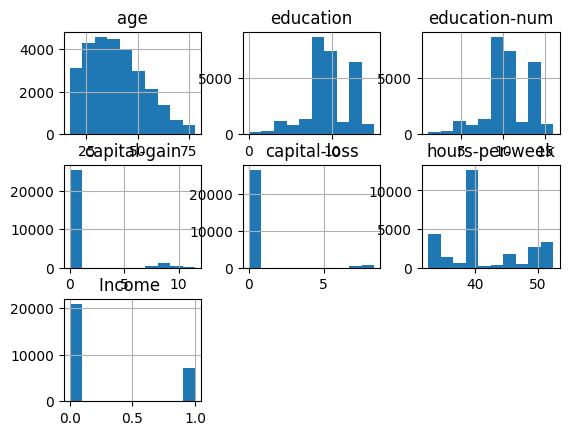

In [72]:
df.hist()

In [73]:
print("Duplicates in X_final :", X_final.duplicated().sum())



Duplicates in X_final : 710


In [74]:
X_final.select_dtypes(include='object').columns

Index([], dtype='str')

In [75]:
X_final.info()

<class 'pandas.DataFrame'>
Index: 28040 entries, 0 to 32536
Data columns (total 89 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        28040 non-null  float64
 1   education                                  28040 non-null  float64
 2   education-num                              28040 non-null  float64
 3   capital-gain                               28040 non-null  float64
 4   capital-loss                               28040 non-null  float64
 5   hours-per-week                             28040 non-null  float64
 6   sex_Female                                 28040 non-null  bool   
 7   sex_Male                                   28040 non-null  bool   
 8   workclass_Federal-gov                      28040 non-null  bool   
 9   workclass_Local-gov                        28040 non-null  bool   
 10  workclass_Never-worked                

In [76]:
X_final.select_dtypes(include='number').columns

Index(['age', 'education', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='str')

In [77]:
X_final.describe()

,age,education,education-num,capital-gain,capital-loss,hours-per-week
count,2.804000e+04,2.804000e+04,2.804000e+04,2.804000e+04,28040.000000,2.804000e+04
mean,-2.493488e-16,-4.814662e-17,-4.814662e-17,-4.662620e-17,0.000000,3.740232e-16
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018,1.000018e+00
min,-1.693788e+00,-3.422339e+00,-3.422339e+00,-3.234615e-01,-0.238174,-1.445472e+00
25%,-7.963450e-01,-4.214865e-01,-4.214865e-01,-3.234615e-01,-0.238174,-2.437668e-01
50%,-1.232624e-01,-4.637997e-02,-4.637997e-02,-3.234615e-01,-0.238174,-2.437668e-01
75%,6.993940e-01,1.078940e+00,1.078940e+00,-3.234615e-01,-0.238174,5.573702e-01
max,2.868216e+00,2.204259e+00,2.204259e+00,4.078688e+00,4.707136,1.759076e+00


In [78]:
X_final.mean()
X_final.std()

age                               1.000018
education                         1.000018
education-num                     1.000018
capital-gain                      1.000018
capital-loss                      1.000018
                                    ...   
native-country_Thailand           0.025329
native-country_Trinadad&Tobago    0.026022
native-country_United-States      0.299434
native-country_Vietnam            0.048824
native-country_Yugoslavia         0.023881
Length: 89, dtype: float64

In [79]:
X_final.columns

Index(['age', 'education', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'sex_Female', 'sex_Male', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay',
       'marital-status_Divorced', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupat

In [80]:
df[numeric_cols].head()
X_final.head()

,age,education,education-num,capital-gain,capital-loss,hours-per-week,sex_Female,sex_Male,workclass_Federal-gov,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,-0.048475,1.078940,1.078940,2.614937,-0.238174,-0.243767,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.774181,1.078940,1.078940,-0.323461,-0.238174,-1.445472,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.123262,-0.421486,-0.421486,-0.323461,-0.238174,-0.243767,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.998542,-1.171700,-1.171700,-0.323461,-0.238174,-0.243767,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.871132,1.078940,1.078940,-0.323461,-0.238174,-0.243767,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [81]:
np.isclose(X_final.mean(), 0, atol=1e-1)
np.isclose(X_final.std(), 1, atol=1e-1)

array([ True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])